# Clasificador con fine-tuning

In [ ]:
import os
import torch
import joblib
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
from datasets import Dataset
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

df = pd.read_csv('5k_resenias.csv', sep=';')
df = df.dropna(subset=['review_text', 'review_rating'])

In [ ]:
def mapear_calificacion(rating):
    if rating >= 4:
        return "positivo"
    elif rating <= 2:
        return "negativo"
    else:
        return "neutral"

def mapear_etiqueta(rating):
    if rating >= 4:
        return 2
    elif rating <= 2:
        return 0
    else:
        return 1

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {"accuracy": acc, "f1": f1}


## Polaridad usando zero-shot

Un zero-shot sirve para determinar si un texto encaja con una etiqueta que puede cambiar en cualquier momento sin necesidad de reentrenar el modelo. Comparar textos contra etiquetas y mide cuál encaja mejor "lógicamente"

In [ ]:
df['true_label'] = df['review_rating'].apply(mapear_calificacion)

device = 0 if torch.cuda.is_available() else -1

clasificador = pipeline(
    "zero-shot-classification",
    model="dccuchile/distilbert-base-spanish-uncased",
    device=device
)

etiquetas_candidatas = ["positivo", "neutral", "negativo"]
predicciones = []

for texto in tqdm(df['review_text'].tolist(), desc="Clasificando reseñas"):
    resultado = clasificador(texto, etiquetas_candidatas)
    predicciones.append(resultado['labels'][0])

df['predicted_label'] = predicciones

### Metricas

Accuracy: 0.3639
F1-Score (Weighted): 0.4494


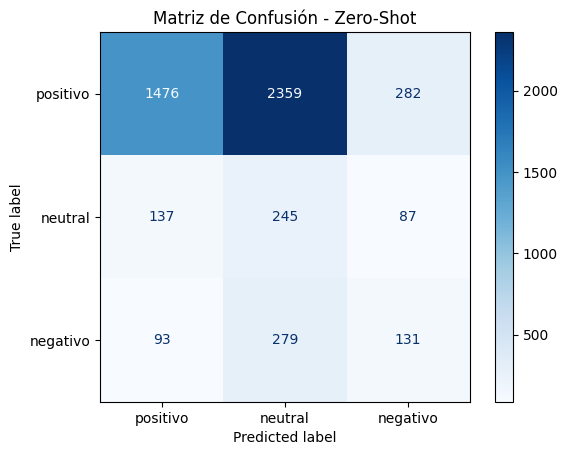

In [ ]:
y_true = df['true_label']
y_pred = df['predicted_label']

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
cm = confusion_matrix(y_true, y_pred, labels=etiquetas_candidatas)

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas_candidatas)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Zero-Shot")
plt.show()

## Polaridad usando fine-tuning

In [ ]:
df['label'] = df['review_rating'].apply(mapear_etiqueta)

train_df, val_df = train_test_split(
    df[['review_text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

train_dataset = Dataset.from_pandas(train_df, preserve_index=False) # Omite el índice original de pandas
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

In [ ]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weight_device = class_weights.to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weight_device)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [ ]:
model_name = "dccuchile/distilbert-base-spanish-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["review_text"], padding="max_length", truncation=True, max_length=128)


tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3) # Neutro, positivo, negativo

training_args = TrainingArguments(
    output_dir="./checkpoints_distilbeto_balanced",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=100,
    learning_rate=2e-5, # 0.00002 => se adapta sin olvidar lo que el modelo ya sabe
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01, # Regularizacion para prevenir overfitting
    load_best_model_at_end=True,
    save_total_limit=3,
    metric_for_best_model="f1"
)


trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

trainer.train()

In [ ]:
trainer.save_model("./modelo_final_distilbeto_balanced")
tokenizer.save_pretrained("./modelo_final_distilbeto_balanced")

In [ ]:
drive.mount('/content/drive')

ruta_guardado_drive = '/content/drive/MyDrive/modelo_distilbeto_resenias'

trainer.save_model(ruta_guardado_drive)
tokenizer.save_pretrained(ruta_guardado_drive)

### Metricas

Accuracy: 0.9253
F1-Score (Weighted): 0.9273


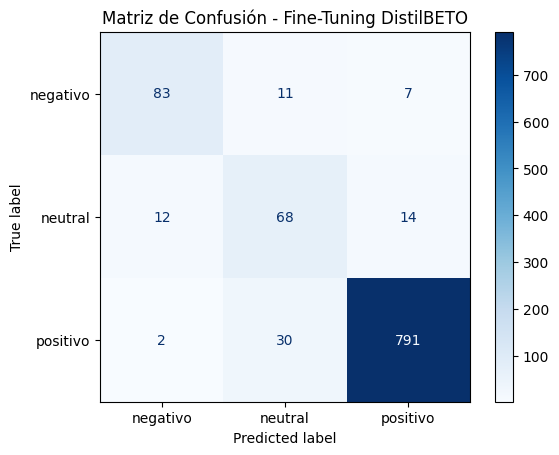

In [ ]:
predicciones_raw = trainer.predict(tokenized_val)

y_pred = np.argmax(predicciones_raw.predictions, axis=-1)
y_true = predicciones_raw.label_ids

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

etiquetas = ["negativo", "neutral", "positivo"]
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Fine-Tuning DistilBETO")
plt.show()

## Clasificador tipo de lugar usando fine-tuning

In [ ]:
df['categoria'] = np.nan

df.loc[
    df['business_name'].str.contains(
        'Museo del Prado|Palacio Real|Catedral de la Almudena',
        case=False,
        na=False
    ),
    'categoria'
] = 'Historicos'

df.loc[
    df['business_name'].str.contains(
        'Parque Güell|Volcán Arenal',
        case=False,
        na=False
    ),
    'categoria'
] = 'Aire libre'

df.loc[
    df['business_name'].str.contains(
        'Kalambu Hot Springs|Museo de los Niños',
        case=False,
        na=False
    ),
    'categoria'
] = 'Atracciones'

In [ ]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['categoria'])
numero_categorias = len(label_encoder.classes_)

train_df, val_df = train_test_split(
    df[['review_text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

diccionario_id_etiqueta = {i: cat for i, cat in enumerate(label_encoder.classes_)}
diccionario_etiqueta_id = {cat: i for i, cat in enumerate(label_encoder.classes_)}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=numero_categorias,
    id2label=diccionario_id_etiqueta,
    label2id=diccionario_etiqueta_id,
    ignore_mismatched_sizes=True
)

training_args.output_dir = "./checkpoints_distilbeto_categorias"

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics
)

trainer.train()

In [ ]:
trainer.save_model("./modelo_categorias_distilbeto")
tokenizer.save_pretrained("./modelo_categorias_distilbeto")

### Metricas

=== Reporte de Clasificación por Categoría ===
              precision    recall  f1-score   support

  Aire libre       0.76      0.71      0.73       189
 Atracciones       0.96      0.97      0.97       418
  Historicos       0.89      0.91      0.90       411

    accuracy                           0.90      1018
   macro avg       0.87      0.86      0.87      1018
weighted avg       0.90      0.90      0.90      1018



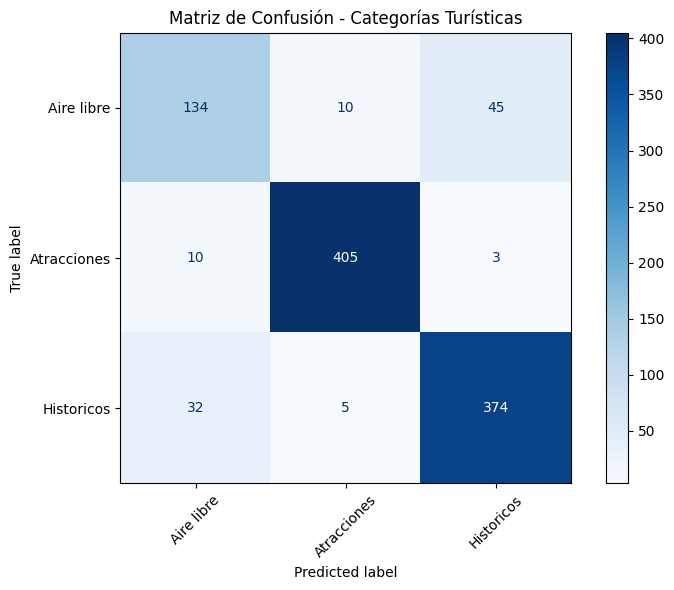

In [ ]:
predictions = trainer.predict(tokenized_val)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

nombres_categorias = list(label_encoder.classes_)

print("=== Reporte de Clasificación por Categoría ===")
print(classification_report(y_true, y_pred, target_names=nombres_categorias))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_categorias)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Matriz de Confusión - Categorías Turísticas")
plt.tight_layout()
plt.show()

### Guardar el modelo y probarlo

In [ ]:
drive.mount('/content/drive')

drive_dir = '/content/drive/MyDrive/modelo_categorias_distilbeto'
os.makedirs(drive_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
trainer.save_model(drive_dir)
tokenizer.save_pretrained(drive_dir)

joblib.dump(label_encoder, f"{drive_dir}/label_encoder.joblib")

print(f"Modelo y artefactos guardados exitosamente en: {drive_dir}")

In [ ]:
drive.mount('/content/drive')

drive_dir = '/content/drive/MyDrive/modelo_categorias_distilbeto'

label_encoder = joblib.load(f"{drive_dir}/label_encoder.joblib")

clasificador_categorias = pipeline(
    "text-classification",
    model=drive_dir,
    tokenizer=drive_dir
)

resenia_nueva = ["El museo tiene exposiciones fascinantes y la atención fue excelente."]
resultado = clasificador_categorias(resenia_nueva)

print(f"Texto: {resenia_nueva[0]}")
print(f"Categoría Predicha: {resultado[0]['label']} (Confianza: {resultado[0]['score']:.2%})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Texto: El museo tiene exposiciones fascinantes y la atención fue excelente.
Categoría Predicha: Atracciones (Confianza: 71.75%)


In [ ]:
resenia_nueva = ["¿Los guias son amables con las personas nuevas?"]
resultado = clasificador_categorias(resenia_nueva)

print(f"Texto: {resenia_nueva[0]}")
print(f"Categoría Predicha: {resultado[0]['label']} (Confianza: {resultado[0]['score']:.2%})")

Texto: ¿Los guias son amables con las personas nuevas?
Categoría Predicha: Atracciones (Confianza: 89.13%)
